In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/code/compositional`


In [2]:
using DataFrames, CairoMakie, FHist
using Distributions, Statistics, SpecialFunctions
using JLD2, CSV, LaTeXStrings

In [3]:
include("./utils.jl")
using .Utils

In [327]:
# @load "./Data/processed/microbiome.jld2" MICROBIOME;
# @load "./Data/processed/genetic.jld2" GENETIC;
# @load "./Data/processed/books.jld2" BOOKS;
# @load "./Data/processed/mobility.jld2" MOBILITY;
@load "./Data/processed/null_model.jld2" NULL_MODEL;

In [328]:
Utils.df_filter!(NULL_MODEL; min_samples=5e1, min_nreads=1e4);
out = Utils.compute_AFD(NULL_MODEL; occ=1, bins=50, plot=false, verbose=true, save=true, filename="./Data/AFD/null_afd");

NULL


In [329]:
### Import distributions ###
# AFD
@load "./Data/AFD/microbiome_afd.jld2" afd_out
microbiome_afd = deepcopy(afd_out);
@load "./Data/AFD/genetic_afd.jld2" afd_out
genetic_afd = deepcopy(afd_out);
@load "./Data/AFD/books_afd.jld2" afd_out
books_afd = deepcopy(afd_out);
@load "./Data/AFD/mobility_afd.jld2" afd_out
mobility_afd = deepcopy(afd_out);
@load "./Data/AFD/null_afd.jld2" afd_out
null_afd = deepcopy(afd_out);
AFDs = [microbiome_afd, genetic_afd, books_afd, mobility_afd, null_afd]

# Clear memory
afd_out = nothing;

In [330]:
fig = Figure(size = (1000, 500))
ax1 = Axis(fig[1, 1]; yscale=log10, limits=((-10.5,9.5),(1e-16,1e1)),
            xlabel=L"\text{z}", ylabel=L"\text{pdf}", title=L"\text{(a) AFD}",
            xlabelsize=18, ylabelsize=18, titlesize=18)

# markers, colors and labels to distinguish different datasets
shapes = (:circle, :rect, :diamond, :utriangle, 
          :dtriangle, :xcross, :cross, :star5, :hexagon)
colors = (:darkorange2, :seagreen1, :dodgerblue3, :chartreuse2, :ghostwhite)
env_labels = ["Mi", "Ge", "Bo", "Mo", "Nu"];

# shared containers
all_plots   = Plot[]
all_labels  = String[]
seen_labels = Set{String}()

# --- AFD ---
for (j, afd) in enumerate(AFDs)
    for (i, key) in enumerate(keys(afd))
        x, y = afd[key]
        lbl = "$(env_labels[j]) $key"
        # decide if this one goes in the legend
        show_label = lbl ∉ seen_labels ? lbl : ""
        if lbl ∉ seen_labels
            push!(seen_labels, lbl)
            sc = scatter!(ax1, x, 10 .^ log.(y);
                          label=lbl,
                          color=colors[j], marker=shapes[i],
                          markersize=12, strokewidth=0.8, strokecolor=:black)
            push!(all_plots, sc)
            push!(all_labels, lbl)
        else
            scatter!(ax1, x, 10 .^ log.(y);
                     label="",
                     color=colors[j], marker=shapes[i],
                     markersize=12, strokewidth=0.8, strokecolor=:black)
        end
    end
end

zrange = -10:0.01:10;
# lines!(ax1, zrange, 10 .^ Utils.lrg(zrange, 2); color=:red, linewidth=2.5, linestyle=:solid);
# lines!(ax1, zrange, 10 .^ Utils.lrln(zrange, 1); color=:magenta, linewidth=2.5, linestyle=:dashdot);
# lines!(ax1, zrange, 10 .^ Utils.lrb(zrange, 1, 100); color=:magenta, linewidth=2.5, linestyle=:dashdot);

# lines!(ax1, zrange, 10 .^ Utils.func(zrange, 1, 20); color=:red, linewidth=2.5, linestyle=:solid);

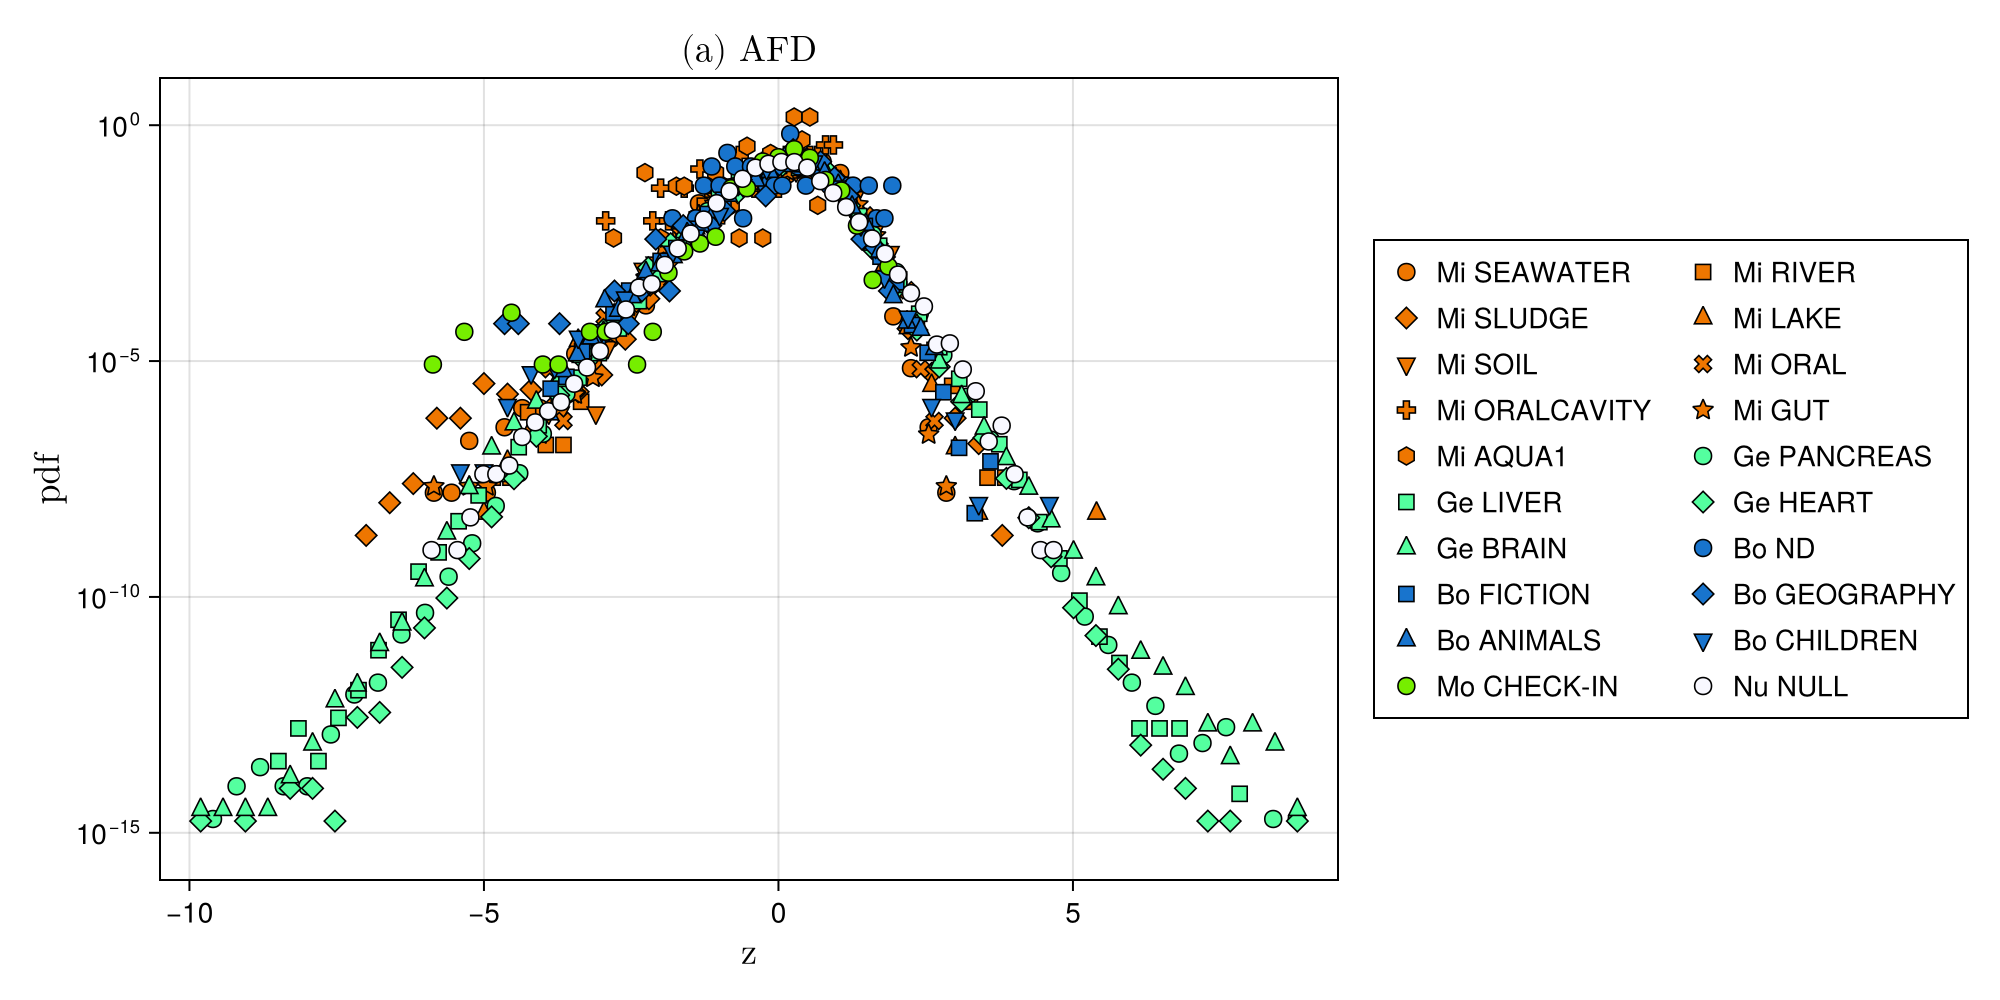

In [331]:
# Legend
fig[1, 2] = Legend(fig, all_plots, all_labels;
    title       = "Data",
    orientation = :vertical,
    nbanks      = 2,
    labelsize   = 14
)

fig

In [333]:
out = Utils.compute_MAD(NULL_MODEL; c=nothing, bins=30, plot=false, verbose=true, save=true, filename="./Data/MAD/null_mad");

NULL


In [336]:
# MAD cutoff
@load "./Data/MAD/microbiome_mad_c.jld2" mad_out
microbiome_mad_c = deepcopy(mad_out)
@load "./Data/MAD/genetic_mad_c.jld2" mad_out
genetic_mad_c = deepcopy(mad_out)
@load "./Data/MAD/books_mad_c.jld2" mad_out
books_mad_c = deepcopy(mad_out)
@load "./Data/MAD/mobility_mad_c.jld2" mad_out
mobility_mad_c = deepcopy(mad_out)
@load "./Data/MAD/null_mad.jld2" mad_out
null_mad = deepcopy(mad_out);
MADs_c = [microbiome_mad_c, genetic_mad_c, books_mad_c, mobility_mad_c, null_mad]

mad_out = nothing;